# 3.2.3 Đánh Giá Mô Hình 
Notebook này tổng hợp đánh giá đầy đủ cho bài toán phân lớp theo yêu cầu: chỉ số cơ bản, confusion matrix, ROC/AUC (nhị phân), loss theo epoch, decision boundary 2D, bảng so sánh mô hình, 5-fold CV, Precision-Recall + AP, McNemar test, và reliability diagram.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

### Dữ liệu và artifact được load từ notebook 03
Cell load bên dưới lấy trực tiếp artifact `evaluation_artifacts_from_03.joblib` và khởi tạo các nhóm dữ liệu sau để đánh giá custom models:
- Dữ liệu đã preprocess: `X_train`, `X_val`, `X_test` cùng nhãn `y_train`, `y_val`, `y_test`.
- Metadata: `class_labels`, `feature_names_processed`, `class_weight_dict`, và `task_coverage`.
- Payload dự đoán/xác suất cho đánh giá: `multiclass_test_predictions`, `multiclass_test_probabilities`, `task3_custom_test_predictions`, `task3_custom_test_probabilities`.
- Tập hợp train+val cho CV: `X_cv`, `y_cv`.
Nếu thiếu key quan trọng, cell load sẽ báo lỗi để quay lại notebook 03 chạy đủ và export lại artifact theo schema mới.

In [2]:
artifact_path = '../results/evaluation_artifacts_from_03.joblib'
if not os.path.exists(artifact_path):
    raise FileNotFoundError(
        f'Không tìm thấy artifact: {artifact_path}. Hãy chạy cell export ở notebook 03 trước.'
    )

artifacts = joblib.load(artifact_path)

X_train = np.asarray(artifacts['X_train_processed'])
X_val = np.asarray(artifacts['X_val_processed'])
X_test = np.asarray(artifacts['X_test_processed'])
y_train = np.asarray(artifacts['y_train'])
y_val = np.asarray(artifacts['y_val'])
y_test = np.asarray(artifacts['y_test'])
class_labels = np.asarray(artifacts['class_labels'])
feature_names_processed = artifacts.get('feature_names_processed', None)
class_weight_dict = artifacts.get('class_weight_dict', None)

X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

multiclass_test_predictions = artifacts.get('multiclass_test_predictions', {})
multiclass_test_probabilities = artifacts.get('multiclass_test_probabilities', {})

task3_pred_payload = artifacts.get('task3_custom_test_predictions', {})
task3_proba_payload = artifacts.get('task3_custom_test_probabilities', {})

if not isinstance(task3_pred_payload, dict) or len(task3_pred_payload) == 0:
    raise KeyError(
        'Thiếu key task3_custom_test_predictions trong artifact. Hãy chạy lại notebook 03 và export artifact schema mới.'
    )
if not isinstance(task3_proba_payload, dict) or len(task3_proba_payload) == 0:
    raise KeyError(
        'Thiếu key task3_custom_test_probabilities trong artifact. Hãy chạy lại notebook 03 và export artifact schema mới.'
    )

optional_eval_keys = [
    'multiclass_results',
    'multiclass_test_predictions',
    'preds_lda',
    'preds_qda',
    'fisher_scores',
    'fisher_top_indices',
    'gd_binary_loss_history',
    'newton_binary_loss_history',
    'task_coverage',
]
missing_optional = [k for k in optional_eval_keys if k not in artifacts]

print('Loaded artifact keys:', sorted(list(artifacts.keys())))
print('Train/Val/Test shape:', X_train.shape, X_val.shape, X_test.shape)
print('Classes:', class_labels)
if 'task_coverage' in artifacts:
    print('Task coverage from notebook 03:', artifacts['task_coverage'])
if missing_optional:
    print('Optional evaluation keys missing:', missing_optional)
    print('Gợi ý: chạy đầy đủ các cell Task 1/2/3 mô hình trong notebook 03 rồi export lại.')

Loaded artifact keys: ['X_test_processed', 'X_train_processed', 'X_val_processed', 'class_labels', 'class_weight_dict', 'feature_names_processed', 'fisher_scores', 'fisher_top_indices', 'gd_binary_loss_history', 'gd_binary_test_proba', 'lambda_tuning_l1', 'lambda_tuning_l2', 'multiclass_results', 'multiclass_test_predictions', 'multiclass_test_probabilities', 'multiclass_val_predictions', 'newton_binary_loss_history', 'newton_binary_test_proba', 'preds_lda', 'preds_qda', 'proba_lda', 'proba_qda', 'seed', 'shapes', 'task3_custom_test_predictions', 'task3_custom_test_probabilities', 'task_coverage', 'y_test', 'y_train', 'y_val']
Train/Val/Test shape: (406707, 56) (58102, 56) (116203, 56)
Classes: [1 2 3 4 5 6 7]
Task coverage from notebook 03: {'task1_multiclass_results': True, 'task1_binary_history': True, 'task1_multiclass_test_predictions': True, 'task2_preds_lda': True, 'task2_preds_qda': True, 'task2_fisher_scores': True, 'task3_lambda_tuning_l1': True, 'task3_lambda_tuning_l2': Tru

### Yêu cầu kết quả nạp dữ liệu
Nếu cell load in đúng key và kích thước train/val/test, luồng dữ liệu đầu vào cho notebook 04 đã sẵn sàng.
Notebook 04 hiện dùng schema mới của artifact; nếu thiếu key Task 3 (`task3_custom_test_predictions`, `task3_custom_test_probabilities`) thì cần quay lại notebook 03 chạy lại đầy đủ và export lại artifact.

## 1) Các Chỉ Số Đánh Giá Cơ Bản
### Lý thuyết
Với bài toán phân lớp đa lớp, các chỉ số cần báo cáo trên tập test:
- Accuracy: tỷ lệ dự đoán đúng trên tổng số mẫu.
- Precision theo từng lớp: $P_k = \frac{TP_k}{TP_k + FP_k}$.
- Recall theo từng lớp: $R_k = \frac{TP_k}{TP_k + FN_k}$.
- F1-score theo từng lớp: $F1_k = 2\frac{P_kR_k}{P_k+R_k}$.
Ngoài ra dùng macro-average để cân bằng ảnh hưởng giữa các lớp.

In [3]:
# Đánh giá chỉ dùng output custom export từ notebook 03
predictions = {}
probabilities = {}
per_class_tables = {}
summary_rows = []

# Task 1 custom logistic strategies
if isinstance(multiclass_test_predictions, dict):
    if 'One-vs-Rest' in multiclass_test_predictions:
        predictions['Logistic OvR (custom from 03)'] = np.asarray(multiclass_test_predictions['One-vs-Rest'])
    if 'One-vs-One' in multiclass_test_predictions:
        predictions['Logistic OvO (custom from 03)'] = np.asarray(multiclass_test_predictions['One-vs-One'])
    if 'Direct Softmax' in multiclass_test_predictions:
        predictions['Logistic Softmax Direct (custom from 03)'] = np.asarray(multiclass_test_predictions['Direct Softmax'])

if isinstance(multiclass_test_probabilities, dict):
    if 'Direct Softmax' in multiclass_test_probabilities:
        probabilities['Logistic Softmax Direct (custom from 03)'] = np.asarray(multiclass_test_probabilities['Direct Softmax'])

# Task 2 custom LDA/QDA
if artifacts.get('preds_lda', None) is not None:
    predictions['LDA (custom from 03)'] = np.asarray(artifacts['preds_lda'])
if artifacts.get('preds_qda', None) is not None:
    predictions['QDA (custom from 03)'] = np.asarray(artifacts['preds_qda'])
if artifacts.get('proba_lda', None) is not None:
    probabilities['LDA (custom from 03)'] = np.asarray(artifacts['proba_lda'])
if artifacts.get('proba_qda', None) is not None:
    probabilities['QDA (custom from 03)'] = np.asarray(artifacts['proba_qda'])

# Task 3 custom regularized logistic outputs
if isinstance(task3_pred_payload, dict):
    for name, y_hat in task3_pred_payload.items():
        if y_hat is not None:
            predictions[name] = np.asarray(y_hat)
if isinstance(task3_proba_payload, dict):
    for name, y_prob in task3_proba_payload.items():
        if y_prob is not None:
            probabilities[name] = np.asarray(y_prob)

if not predictions:
    raise RuntimeError('Không tìm thấy dự đoán custom trong artifact. Hãy chạy lại notebook 03 và export artifact mới.')

for model_name, y_pred in predictions.items():
    if y_pred.shape[0] != y_test.shape[0]:
        print(f"[WARN] Skip {model_name}: prediction length mismatch ({y_pred.shape[0]} vs {y_test.shape[0]}).")
        continue

    p, r, f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=class_labels, zero_division=0
    )

    per_class_tables[model_name] = pd.DataFrame(
        {
            'class': class_labels,
            'precision': p,
            'recall': r,
            'f1_score': f1,
            'support': support,
        }
    )

    summary_rows.append(
        {
            'model': model_name,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(by='f1_macro', ascending=False).reset_index(drop=True)
summary_df

,model,accuracy,precision_macro,recall_macro,f1_macro
0,LDA (custom from 03),0.679853,0.486090,0.579241,0.512252
1,Logistic OvO (custom from 03),0.694956,0.614494,0.326947,0.331499
2,Logistic Softmax Direct (custom from 03),0.689199,0.324946,0.308579,0.299426
3,Logistic OvR (custom from 03),0.676996,0.277177,0.294942,0.285181
4,Regularized Logistic L2 (custom from 03),0.679414,0.278544,0.292729,0.284697
5,Regularized Logistic L1 (custom from 03),0.678735,0.278531,0.291690,0.284119
6,QDA (custom from 03),0.223299,0.335466,0.544051,0.233464


In [4]:
# Hiển thị một bảng gọn cho mỗi mô hình (gồm per-class + accuracy/macro avg/weighted avg)
for model_name in per_class_tables.keys():
    print(f'===== {model_name} - per-class metrics =====')

    class_df = per_class_tables[model_name].copy()

    y_pred = predictions[model_name]
    total_support = int(len(y_test))
    macro_p = precision_score(y_test, y_pred, average='macro', zero_division=0)
    macro_r = recall_score(y_test, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    weighted_p = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_r = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    acc = accuracy_score(y_test, y_pred)

    summary_rows = pd.DataFrame([
        {'class': 'accuracy', 'precision': np.nan, 'recall': np.nan, 'f1_score': acc, 'support': total_support},
        {'class': 'macro avg', 'precision': macro_p, 'recall': macro_r, 'f1_score': macro_f1, 'support': total_support},
        {'class': 'weighted avg', 'precision': weighted_p, 'recall': weighted_r, 'f1_score': weighted_f1, 'support': total_support},
    ])

    display_df = pd.concat([class_df, summary_rows], ignore_index=True)
    display(display_df)
    print()

===== Logistic OvR (custom from 03) - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.674609,0.656250,0.665303,42368
1,2,0.689214,0.823953,0.750585,56661
2,3,0.576414,0.584394,0.580376,7151
3,4,0.000000,0.000000,0.000000,549
4,5,0.000000,0.000000,0.000000,1899
5,6,0.000000,0.000000,0.000000,3473
6,7,0.000000,0.000000,0.000000,4102
7,accuracy,NaN,NaN,0.676996,116203
8,macro avg,0.277177,0.294942,0.285181,116203
9,weighted avg,0.617500,0.676996,0.644275,116203



===== Logistic OvO (custom from 03) - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.680741,0.704730,0.692528,42368
1,2,0.718111,0.809869,0.761235,56661
2,3,0.620900,0.627325,0.624096,7151
3,4,1.000000,0.003643,0.007260,549
4,5,0.000000,0.000000,0.000000,1899
5,6,0.344562,0.103081,0.158688,3473
6,7,0.937143,0.039980,0.076689,4102
7,accuracy,NaN,NaN,0.694956,116203
8,macro avg,0.614494,0.326947,0.331499,116203
9,weighted avg,0.684667,0.694956,0.669569,116203



===== Logistic Softmax Direct (custom from 03) - per-class metrics =====


...

,class,precision,recall,f1_score,support
0,1,0.638419,0.199325,0.303799,42368
1,2,0.878632,0.114735,0.202966,56661
2,3,0.373368,0.635995,0.470515,7151
3,4,0.124652,0.979964,0.221172,549
4,5,0.033606,0.772512,0.064410,1899
5,6,0.178346,0.138497,0.155916,3473
6,7,0.121238,0.967333,0.215471,4102
7,accuracy,NaN,NaN,0.223299,116203
8,macro avg,0.335466,0.544051,0.233464,116203
9,weighted avg,0.694919,0.223299,0.253052,116203



===== Regularized Logistic L1 (custom from 03) - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.678566,0.660853,0.669592,42368
1,2,0.688391,0.828048,0.751789,56661
2,3,0.582756,0.552930,0.567451,7151
3,4,0.000000,0.000000,0.000000,549
4,5,0.000000,0.000000,0.000000,1899
5,6,0.000000,0.000000,0.000000,3473
6,7,0.000000,0.000000,0.000000,4102
7,accuracy,NaN,NaN,0.678735,116203
8,macro avg,0.278531,0.291690,0.284119,116203
9,weighted avg,0.618932,0.678735,0.645631,116203



===== Regularized Logistic L2 (custom from 03) - per-class metrics =====


,class,precision,recall,f1_score,support
0,1,0.678900,0.662363,0.670529,42368
1,2,0.689661,0.827518,0.752327,56661
2,3,0.581250,0.559222,0.570024,7151
3,4,0.000000,0.000000,0.000000,549
4,5,0.000000,0.000000,0.000000,1899
5,6,0.000000,0.000000,0.000000,3473
6,7,0.000000,0.000000,0.000000,4102
7,accuracy,NaN,NaN,0.679414,116203
8,macro avg,0.278544,0.292729,0.284697,116203
9,weighted avg,0.619580,0.679414,0.646393,116203


### Phân tích kết quả
- `summary_df` cho thấy **LDA (custom from 03)** đứng đầu theo macro-F1 với `f1_macro = 0.5123`, `accuracy = 0.6799`.
- Nhóm logistic custom đa lớp xếp sau: OvO (`f1_macro = 0.3315`) > Softmax Direct (`0.2994`) > OvR (`0.2852`).
- Hai mô hình regularized logistic (L1/L2) có độ chính xác test tương đương (~0.679) nhưng macro-F1 thấp hơn LDA đáng kể, cho thấy mô hình đang thiên về lớp đa số hơn là cân bằng theo lớp.
- **QDA** có `accuracy = 0.2233`, `f1_macro = 0.2335`, thấp nhất trong lần chạy này; phần confusion matrix và error analysis phía sau sẽ chỉ ra các cặp lớp gây lỗi chính.

## 2) Confusion Matrix
### Lý thuyết
Confusion matrix cho ta cái nhìn trực quan về cặp lớp nào dễ bị nhầm lẫn. Mỗi ô $(i, j)$ là số mẫu thuộc lớp thật $i$ nhưng dự đoán thành lớp $j$.

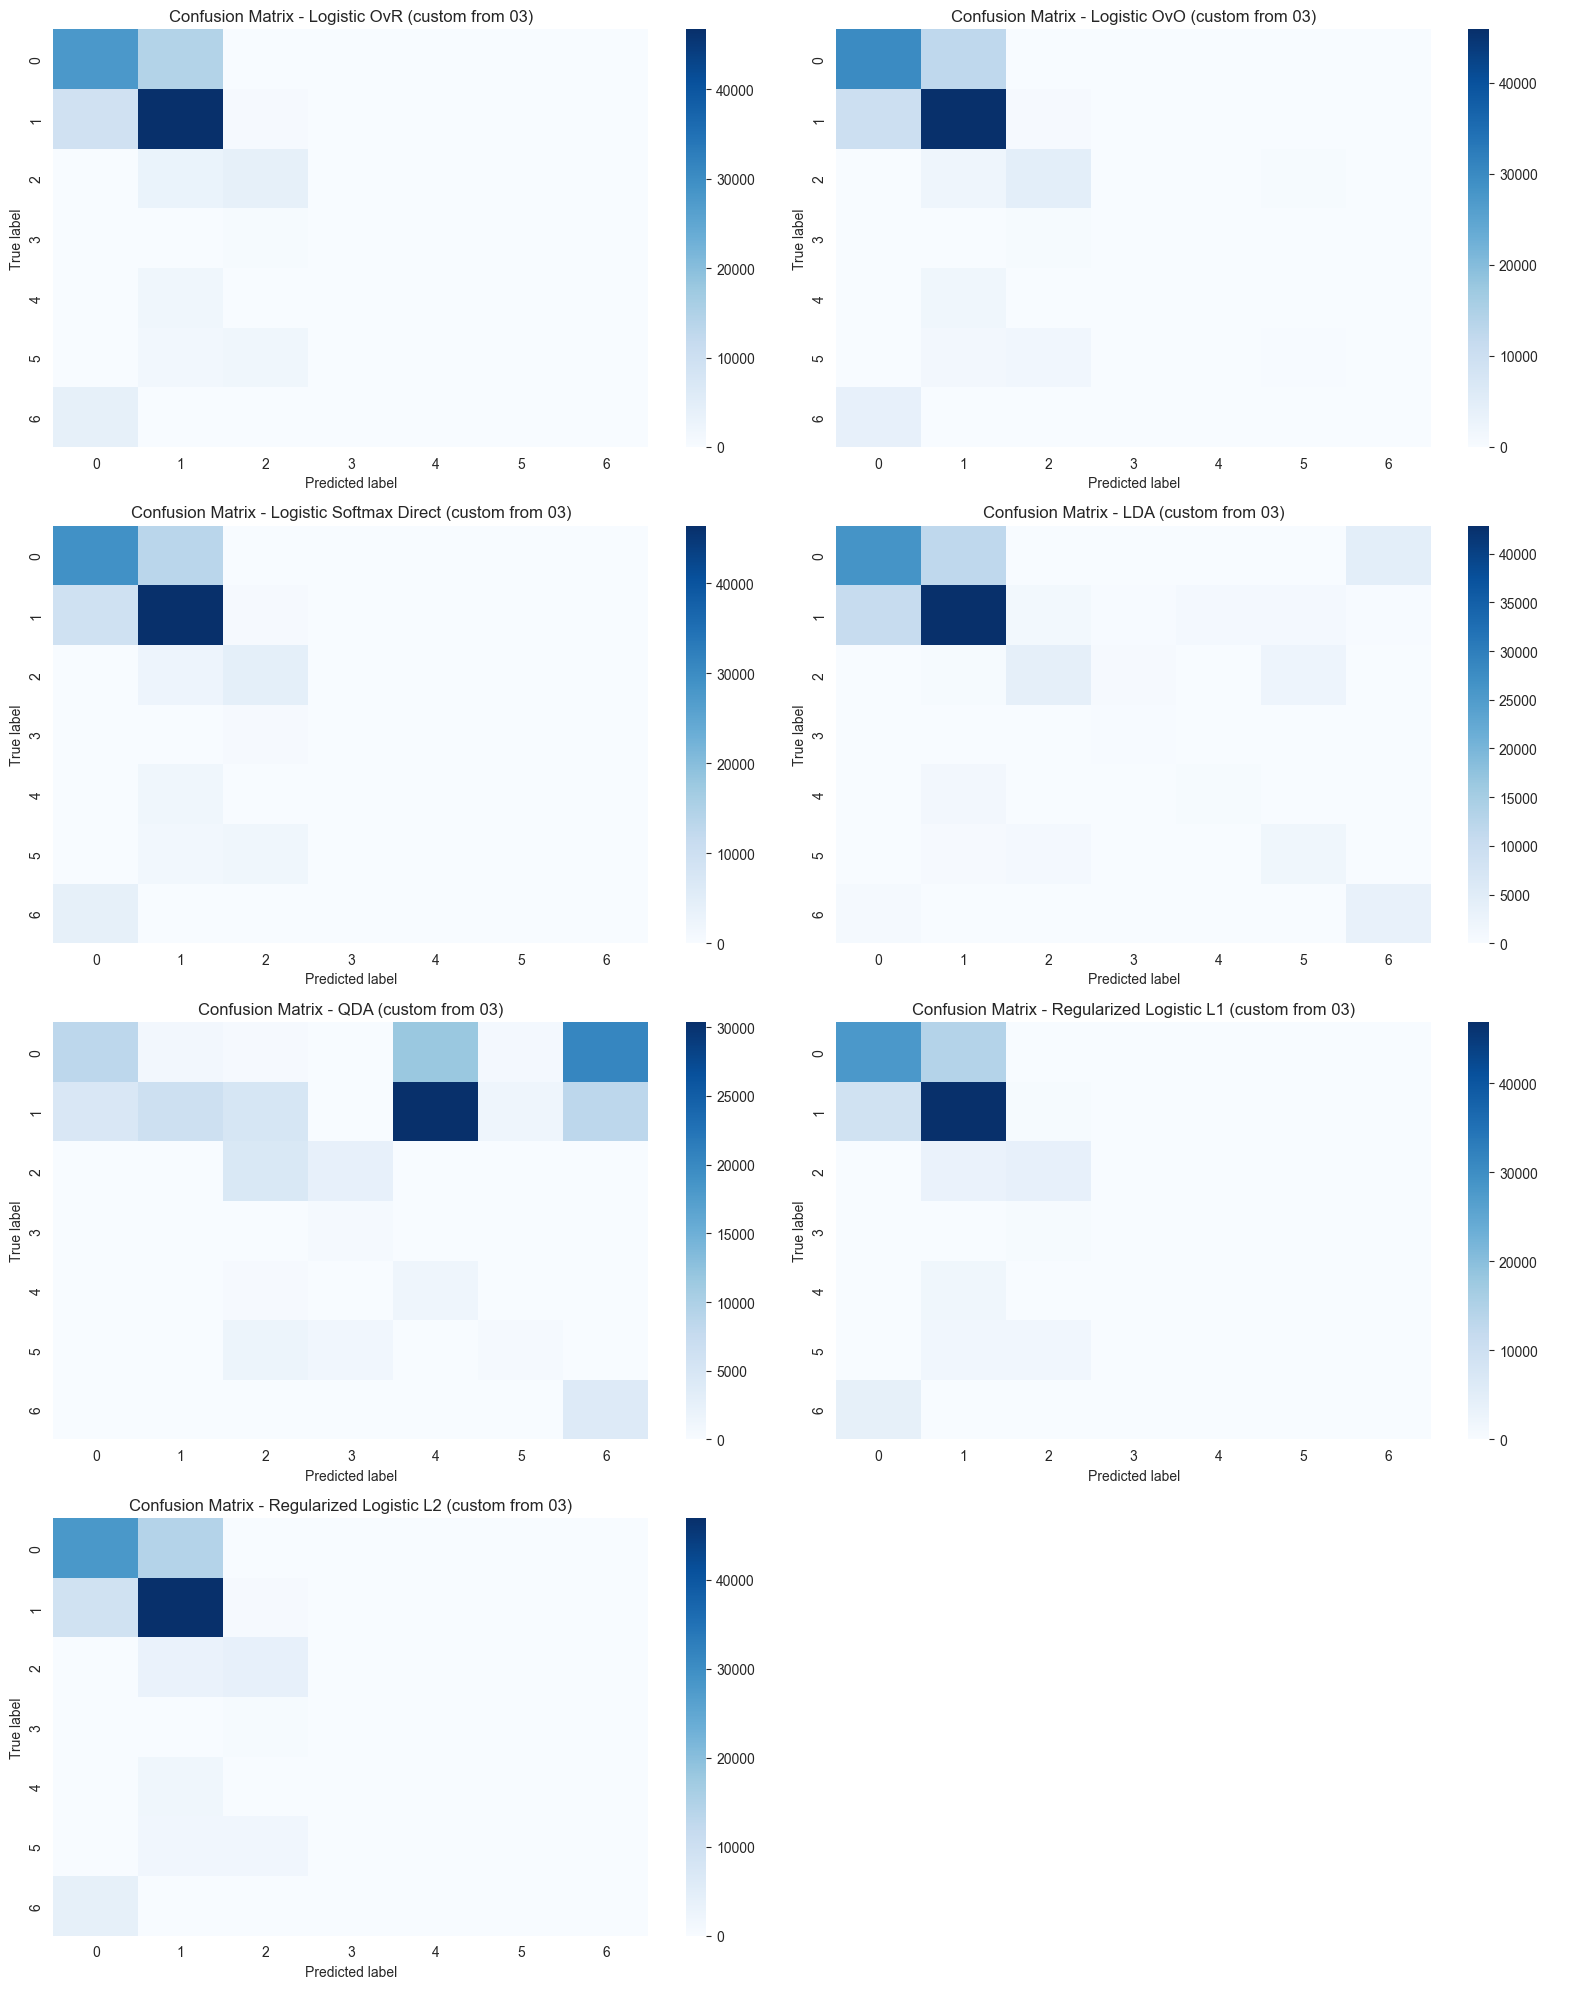

In [5]:
model_names = list(predictions.keys())
n_models = len(model_names)

n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for idx, model_name in enumerate(model_names):
    cm = confusion_matrix(y_test, predictions[model_name], labels=class_labels)
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {model_name}')
    axes[idx].set_xlabel('Predicted label')
    axes[idx].set_ylabel('True label')

for k in range(n_models, len(axes)):
    axes[k].axis('off')

plt.tight_layout()
plt.show()

### Phân tích kết quả
- Các confusion matrix xác nhận khác biệt hành vi giữa mô hình: LDA giữ vùng chéo chính rõ hơn ở nhiều lớp so với các logistic custom còn lại.
- Với LDA, các cặp nhầm lẫn nổi bật (xem thêm error analysis): `1 -> 2` (11566 mẫu), `2 -> 1` (10443 mẫu), và `1 -> 7` (4343 mẫu).
- Điều này giải thích vì sao LDA đạt macro-F1 cao nhất trong phiên chạy hiện tại dù vẫn còn lỗi đáng kể ở một số lớp hiếm.

## 3) ROC Curve + AUC (Nhị phân)
### Lý thuyết
ROC curve biểu diễn trade-off giữa True Positive Rate và False Positive Rate khi thay đổi threshold. Diện tích dưới đường cong (AUC) càng cao thì khả năng phân biệt hai lớp càng tốt.

Với bài toán gốc đa lớp, ta tạo bài toán nhị phân one-vs-rest trên lớp hiếm nhất để đánh giá ROC/AUC.

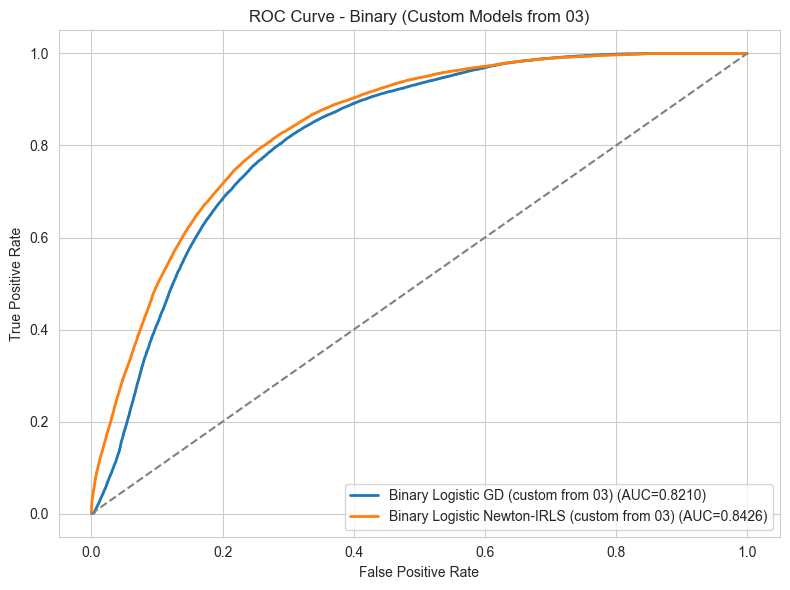

,model,auc
1,Binary Logistic Newton-IRLS (custom from 03),0.842598
0,Binary Logistic GD (custom from 03),0.821044


In [6]:
# ROC/AUC nhị phân dùng trực tiếp xác suất custom từ notebook 03 (GD/Newton)
positive_class = 1
y_test_bin = (y_test == positive_class).astype(int)

binary_probs = {}
binary_auc_rows = []

if artifacts.get('gd_binary_test_proba', None) is not None:
    binary_probs['Binary Logistic GD (custom from 03)'] = np.asarray(artifacts['gd_binary_test_proba']).ravel()
if artifacts.get('newton_binary_test_proba', None) is not None:
    binary_probs['Binary Logistic Newton-IRLS (custom from 03)'] = np.asarray(artifacts['newton_binary_test_proba']).ravel()

if not binary_probs:
    raise RuntimeError('Thiếu xác suất nhị phân custom trong artifact (gd_binary_test_proba/newton_binary_test_proba).')

plt.figure(figsize=(8, 6))
for name, y_prob in binary_probs.items():
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    auc_score = roc_auc_score(y_test_bin, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_score:.4f})')
    binary_auc_rows.append({'model': name, 'auc': float(auc_score)})

plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title('ROC Curve - Binary (Custom Models from 03)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

binary_auc_df = pd.DataFrame(binary_auc_rows).sort_values(by='auc', ascending=False)
binary_auc_df

### Phân tích kết quả
- Trên bài toán nhị phân OVR (lớp dương = 1), **Newton-IRLS** đạt `AUC = 0.8426`, cao hơn **GD** (`AUC = 0.8210`).
- Khoảng chênh ~0.0216 cho thấy Newton-IRLS phân biệt lớp dương tốt hơn trong cùng thiết lập dữ liệu và feature.
- Kết quả này nhất quán với phần loss và calibration bên dưới, nơi Newton-IRLS cũng cho chỉ số tốt hơn.

## 4) Đồ thị Cross-Entropy Loss theo Epoch
### Lý thuyết
Cross-entropy loss phản ánh độ khác biệt giữa nhãn thật và xác suất dự đoán. Khi huấn luyện ổn định, loss giảm dần và hội tụ.

Trong notebook này, ta không huấn luyện lại ở notebook 04 mà dùng trực tiếp lịch sử loss đã export từ notebook 03 cho hai phiên bản logistic nhị phân custom: GD và Newton-IRLS.

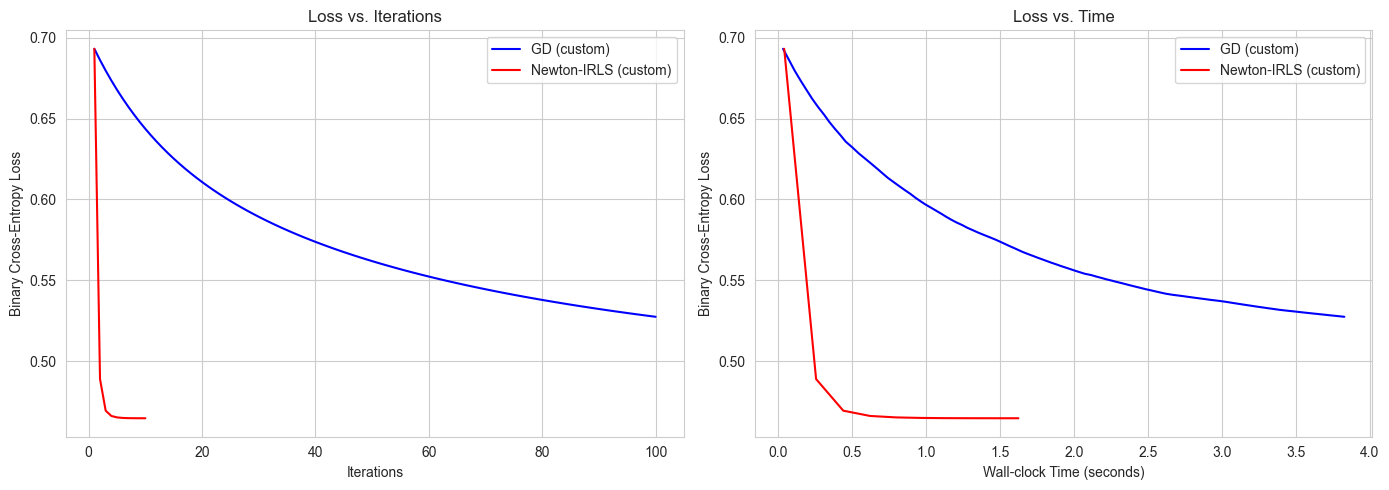

GD final loss: 0.527488
Newton final loss: 0.464768


In [7]:
# Dùng trực tiếp history loss custom từ notebook 03 (GD vs Newton-IRLS)
gd_hist = artifacts.get('gd_binary_loss_history', None)
newton_hist = artifacts.get('newton_binary_loss_history', None)

if gd_hist is None or newton_hist is None:
    raise RuntimeError('Thiếu gd_binary_loss_history/newton_binary_loss_history trong artifact.')

gd_loss = np.asarray(gd_hist.get('loss', []), dtype=float)
gd_time = np.asarray(gd_hist.get('time', []), dtype=float)
newton_loss = np.asarray(newton_hist.get('loss', []), dtype=float)
newton_time = np.asarray(newton_hist.get('time', []), dtype=float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(np.arange(1, len(gd_loss) + 1), gd_loss, label='GD (custom)', color='blue')
ax1.plot(np.arange(1, len(newton_loss) + 1), newton_loss, label='Newton-IRLS (custom)', color='red')
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Binary Cross-Entropy Loss')
ax1.set_title('Loss vs. Iterations')
ax1.legend()

ax2.plot(gd_time, gd_loss, label='GD (custom)', color='blue')
ax2.plot(newton_time, newton_loss, label='Newton-IRLS (custom)', color='red')
ax2.set_xlabel('Wall-clock Time (seconds)')
ax2.set_ylabel('Binary Cross-Entropy Loss')
ax2.set_title('Loss vs. Time')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'GD final loss: {gd_loss[-1]:.6f}')
print(f'Newton final loss: {newton_loss[-1]:.6f}')

### Phân tích kết quả
- Loss cuối của GD là `0.527488`, trong khi Newton-IRLS là `0.464768` (thấp hơn rõ rệt).
- Trên đồ thị theo iteration và theo thời gian, Newton-IRLS giảm loss nhanh ở giai đoạn đầu và hội tụ sớm hơn GD.
- Điều này củng cố kết luận ở ROC/AUC: optimizer Newton-IRLS đang cho chất lượng học tốt hơn trên nhánh logistic nhị phân custom.

## 5) Decision Boundary trong Không Gian 2D
### Lý thuyết
Với dữ liệu nhiều chiều, ta giảm chiều về 2D (ví dụ PCA) để quan sát biên quyết định một cách trực quan. Đồ thị này mang tính minh hoạ, không thay thế đánh giá trên không gian gốc.

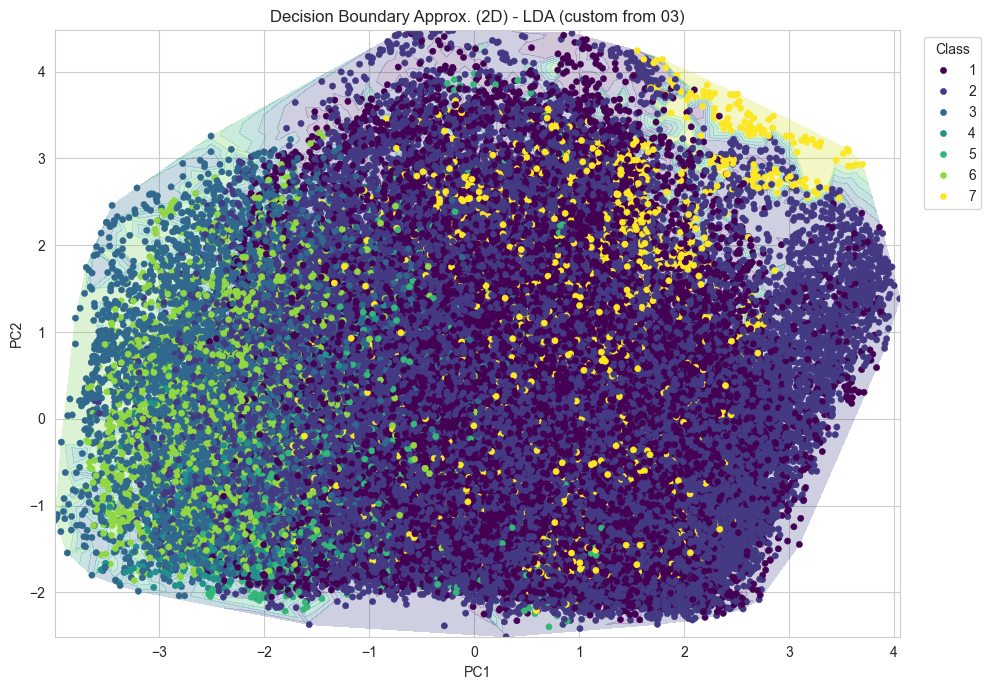

In [8]:
# Minh họa decision boundary 2D từ dự đoán custom (không train thêm model thư viện)
from matplotlib.tri import Triangulation

# Chọn mô hình custom tốt nhất trong summary hiện tại
best_model_name = summary_df.iloc[0]['model']
best_pred = np.asarray(predictions[best_model_name])

pca = PCA(n_components=2, random_state=SEED)
X_test_2d = pca.fit_transform(X_test)

class_to_idx = {c: i for i, c in enumerate(class_labels)}
z_numeric = np.array([class_to_idx[int(c)] for c in best_pred], dtype=float)

tri = Triangulation(X_test_2d[:, 0], X_test_2d[:, 1])

plt.figure(figsize=(10, 7))
plt.tricontourf(tri, z_numeric, levels=np.arange(len(class_labels) + 1) - 0.5, alpha=0.25, cmap='viridis')
sns.scatterplot(
    x=X_test_2d[:, 0],
    y=X_test_2d[:, 1],
    hue=y_test,
    s=20,
    palette='viridis',
    edgecolor=None,
)
plt.title(f'Decision Boundary Approx. (2D) - {best_model_name}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Phân tích kết quả
- Trong lần chạy này, mô hình được chọn để minh họa biên 2D là **LDA (custom from 03)** vì đứng đầu `summary_df` theo macro-F1.
- Biên quyết định cho thấy các vùng lớp tách tương đối rõ ở vài khu vực nhưng vẫn chồng lấn mạnh ở vùng trung tâm, phù hợp với các lỗi chéo quan sát được trong confusion matrix.
- Đây là hình trực quan hóa sau chiếu PCA 2D; quyết định chọn mô hình vẫn ưu tiên theo các chỉ số định lượng trên không gian đặc trưng đầy đủ.

## 6) Bảng So Sánh Tất Cả Mô Hình
### Lý thuyết
Tổng hợp tất cả mô hình trong một bảng thống nhất giúp đối chiếu nhanh giữa metric phân lớp đa lớp và metric nhị phân (AUC/AP) nếu cần.

In [9]:
comparison_multiclass_df = summary_df.copy()
comparison_multiclass_df['auc_binary_ovr'] = np.nan
comparison_multiclass_df['ap_binary_ovr'] = np.nan
comparison_multiclass_df['group'] = 'multiclass'

binary_rows = []
for row in binary_auc_df.itertuples(index=False):
    model_name = row.model
    ap_value = average_precision_score(y_test_bin, binary_probs[model_name])
    binary_rows.append(
        {
            'model': model_name,
            'accuracy': np.nan,
            'precision_macro': np.nan,
            'recall_macro': np.nan,
            'f1_macro': np.nan,
            'auc_binary_ovr': float(row.auc),
            'ap_binary_ovr': float(ap_value),
            'group': 'binary_ovr',
        }
    )

comparison_binary_df = pd.DataFrame(binary_rows)
comparison_df = pd.concat([comparison_multiclass_df, comparison_binary_df], ignore_index=True)
comparison_df

,model,accuracy,precision_macro,recall_macro,f1_macro,auc_binary_ovr,ap_binary_ovr,group
0,LDA (custom from 03),0.679853,0.486090,0.579241,0.512252,NaN,NaN,multiclass
1,Logistic OvO (custom from 03),0.694956,0.614494,0.326947,0.331499,NaN,NaN,multiclass
2,Logistic Softmax Direct (custom from 03),0.689199,0.324946,0.308579,0.299426,NaN,NaN,multiclass
3,Logistic OvR (custom from 03),0.676996,0.277177,0.294942,0.285181,NaN,NaN,multiclass
4,Regularized Logistic L2 (custom from 03),0.679414,0.278544,0.292729,0.284697,NaN,NaN,multiclass
5,Regularized Logistic L1 (custom from 03),0.678735,0.278531,0.291690,0.284119,NaN,NaN,multiclass
6,QDA (custom from 03),0.223299,0.335466,0.544051,0.233464,NaN,NaN,multiclass
7,Binary Logistic Newton-IRLS (custom from 03),NaN,NaN,NaN,NaN,0.842598,0.722663,binary_ovr
8,Binary Logistic GD (custom from 03),NaN,NaN,NaN,NaN,0.821044,0.640464,binary_ovr


### Phân tích kết quả
- Bảng so sánh hợp nhất đã tách đúng 2 nhóm metric: `multiclass` và `binary_ovr`, giúp đọc kết quả không bị nhầm ngữ cảnh.
- Với nhóm multiclass, LDA đang dẫn đầu theo macro-F1 (`0.5123`); với nhóm binary_ovr, Newton-IRLS đang dẫn đầu theo AUC (`0.8426`).
- Vì mục tiêu báo cáo là phân lớp đa lớp, ưu tiên chính nên dựa trên macro-F1/precision/recall theo lớp; AUC/AP/Brier đóng vai trò bổ sung chất lượng xác suất.

## 7) 5-Fold Cross-Validation (mean +- std)
### Lý thuyết
Cross-validation đánh giá độ ổn định của mô hình qua nhiều lần chia dữ liệu. Báo cáo mean +- std của metric giúp ước lượng mức độ dao động và độ tin cậy của kết quả.

In [10]:
# CV summary dùng từ notebook 03 (custom-only, mean +- std cho đủ chỉ số)
cv_rows = []

def _best_row_from_cv(info):
    if not isinstance(info, dict):
        return None
    table = info.get('cv_table', None)
    best_lambda = info.get('best_lambda', None)
    if not isinstance(table, list) or len(table) == 0:
        return None
    if best_lambda is not None:
        for row in table:
            if float(row.get('lambda', np.nan)) == float(best_lambda):
                return row
    return max(table, key=lambda r: r.get('macro_f1_mean', -np.inf))

l1_info = artifacts.get('lambda_tuning_l1', {})
l2_info = artifacts.get('lambda_tuning_l2', {})

for model_name, info in [
    ('Regularized Logistic L1 (custom from 03)', l1_info),
    ('Regularized Logistic L2 (custom from 03)', l2_info),
]:
    best_row = _best_row_from_cv(info)
    if best_row is None:
        continue
    cv_rows.append({
        'model': model_name,
        'accuracy_mean_std': f"{best_row['accuracy_mean']:.4f} +- {best_row['accuracy_std']:.4f}",
        'precision_macro_mean_std': f"{best_row['precision_macro_mean']:.4f} +- {best_row['precision_macro_std']:.4f}",
        'recall_macro_mean_std': f"{best_row['recall_macro_mean']:.4f} +- {best_row['recall_macro_std']:.4f}",
        'f1_macro_mean_std': f"{best_row['macro_f1_mean']:.4f} +- {best_row['macro_f1_std']:.4f}",
        'best_lambda': float(info.get('best_lambda', np.nan)),
    })

# Nếu notebook 03 có export bảng CV tổng hợp custom, ưu tiên dùng bảng này
custom_cv_summary = artifacts.get('custom_cv_summary', None)
if isinstance(custom_cv_summary, list) and len(custom_cv_summary) > 0:
    cv_df = pd.DataFrame(custom_cv_summary)
else:
    cv_df = pd.DataFrame(cv_rows)

if cv_df.empty:
    print('Chưa có cv_table đầy đủ trong artifact. Hãy chạy lại cell tuning ở notebook 03 rồi export lại.')

cv_df

,model,accuracy_mean_std,precision_macro_mean_std,recall_macro_mean_std,f1_macro_mean_std,best_lambda
0,Regularized Logistic L1 (custom from 03),0.6680 +- 0.0005,0.2806 +- 0.0007,0.2743 +- 0.0006,0.2737 +- 0.0006,0.001
1,Regularized Logistic L2 (custom from 03),0.6691 +- 0.0004,0.2800 +- 0.0006,0.2762 +- 0.0006,0.2749 +- 0.0006,0.001


### Phân tích kết quả
- CV 5-fold từ notebook 03 cho thấy hai mô hình regularized logistic có độ ổn định cao (std rất nhỏ).
- L1: `accuracy 0.6680 ± 0.0005`, `precision_macro 0.2806 ± 0.0007`, `recall_macro 0.2743 ± 0.0006`, `f1_macro 0.2737 ± 0.0006` với `best_lambda = 0.001`.
- L2: `accuracy 0.6691 ± 0.0004`, `precision_macro 0.2800 ± 0.0006`, `recall_macro 0.2762 ± 0.0006`, `f1_macro 0.2749 ± 0.0006` với `best_lambda = 0.001`.
- Trong lần chạy này, L2 nhỉnh hơn L1 ở accuracy và macro-F1 trên CV, nhưng chênh lệch nhỏ.

## 8) Precision-Recall Curve và Average Precision (AP)
### Lý thuyết
Precision-Recall curve nhấn mạnh hiệu năng trên lớp dương tính, đặc biệt hữu ích khi mất cân bằng lớp. AP (Average Precision) là diện tích dưới đường PR theo cách tính xếp hạng.

Với bài toán đa lớp, ta dùng one-vs-rest và tổng hợp theo macro-average.

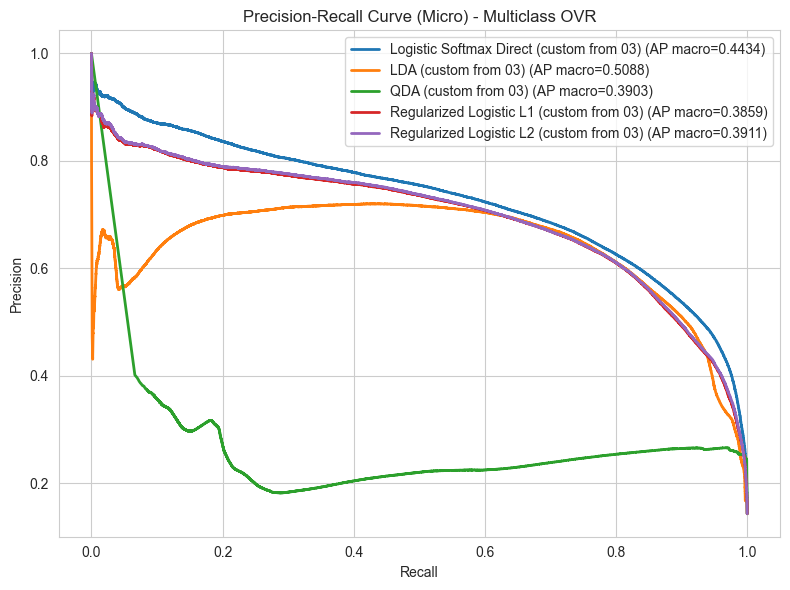

,model,ap_macro_ovr
1,LDA (custom from 03),0.508844
0,Logistic Softmax Direct (custom from 03),0.443383
4,Regularized Logistic L2 (custom from 03),0.391065
2,QDA (custom from 03),0.390277
3,Regularized Logistic L1 (custom from 03),0.385924


In [11]:
y_test_bin_multi = label_binarize(y_test, classes=class_labels)

ap_rows = []
plt.figure(figsize=(8, 6))

for model_name, y_proba in probabilities.items():
    if y_proba is None:
        print(f"[WARN] Skip PR/AP for {model_name}: model không trả về xác suất.")
        continue

    precision_micro, recall_micro, _ = precision_recall_curve(y_test_bin_multi.ravel(), y_proba.ravel())
    ap_macro = average_precision_score(y_test_bin_multi, y_proba, average='macro')
    plt.plot(recall_micro, precision_micro, lw=2, label=f'{model_name} (AP macro={ap_macro:.4f})')
    ap_rows.append({'model': model_name, 'ap_macro_ovr': ap_macro})

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Micro) - Multiclass OVR')
plt.legend()
plt.tight_layout()
plt.show()

ap_df = pd.DataFrame(ap_rows).sort_values(by='ap_macro_ovr', ascending=False)
ap_df

### Phân tích kết quả
- AP macro OVR cao nhất thuộc về **LDA** (`0.5088`), tiếp theo là **Logistic Softmax Direct** (`0.4434`).
- Hai mô hình regularized logistic và QDA nằm nhóm sau (`~0.386-0.391`), phản ánh chất lượng xếp hạng xác suất chưa tốt bằng LDA.
- Xét đồng thời macro-F1 và AP trong lần chạy này, LDA là lựa chọn cân bằng nhất giữa hiệu năng phân lớp và chất lượng xác suất.

## 9) McNemar's Test
### Lý thuyết
McNemar test kiểm định sự khác biệt thống kê giữa hai bộ dự đoán trên cùng một tập test ghép cặp. Giả thuyết $H_0$: hai mô hình có cùng tỉ lệ lỗi. Nếu p-value nhỏ (thường < 0.05), bác bỏ $H_0$.

In [12]:
top2 = summary_df.head(2)['model'].tolist()
model_a, model_b = top2[0], top2[1]

pred_a = predictions[model_a]
pred_b = predictions[model_b]

a = np.sum((pred_a == y_test) & (pred_b == y_test))
b = np.sum((pred_a == y_test) & (pred_b != y_test))
c = np.sum((pred_a != y_test) & (pred_b == y_test))
d = np.sum((pred_a != y_test) & (pred_b != y_test))

table = [[a, b], [c, d]]
test_result = mcnemar(table, exact=False, correction=True)

print(f'So sánh McNemar giữa: {model_a} vs {model_b}')
print('Contingency table [[a,b],[c,d]] =', table)
print(f'Statistic = {test_result.statistic:.4f}')
print(f'p-value = {test_result.pvalue:.6f}')

alpha = 0.05
if test_result.pvalue < alpha:
    print('Kết luận: Có sự khác biệt thống kê giữa hai mô hình (bác bỏ H0).')
else:
    print('Kết luận: Chưa đủ bằng chứng để nói hai mô hình khác biệt thống kê (không bác bỏ H0).')

So sánh McNemar giữa: LDA (custom from 03) vs Logistic OvO (custom from 03)
Contingency table [[a,b],[c,d]] = [[69658, 9343], [11098, 26104]]
Statistic = 150.5071
p-value = 0.000000
Kết luận: Có sự khác biệt thống kê giữa hai mô hình (bác bỏ H0).


### Phân tích kết quả
- McNemar test đang so sánh 2 mô hình đứng đầu theo `summary_df`: **LDA** và **Logistic OvO**.
- Kết quả: `statistic = 150.5071`, `p-value = 0.000000 < 0.05`, nên bác bỏ $H_0$.
- Nghĩa là chênh lệch lỗi giữa hai mô hình có ý nghĩa thống kê trên cùng tập test, không chỉ là dao động ngẫu nhiên.

## 10) Calibration và Reliability Diagram
### Lý thuyết
Calibration đánh giá mức độ phù hợp giữa xác suất dự đoán và tần suất thực tế. Reliability diagram vẽ đường y=x (dự đoán lý tưởng) và đường thực nghiệm. Brier score càng thấp thì calibration càng tốt.

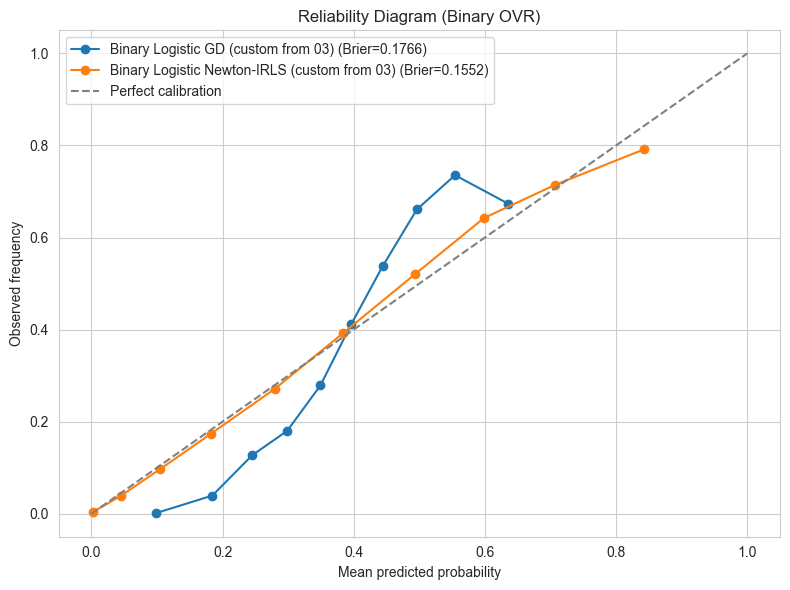

,model,brier_score
1,Binary Logistic Newton-IRLS (custom from 03),0.155175
0,Binary Logistic GD (custom from 03),0.176608


In [13]:
plt.figure(figsize=(8, 6))
brier_rows = []

for name, y_prob in binary_probs.items():
    frac_pos, mean_pred = calibration_curve(y_test_bin, y_prob, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_test_bin, y_prob)
    brier_rows.append({'model': name, 'brier_score': brier})
    plt.plot(mean_pred, frac_pos, marker='o', label=f'{name} (Brier={brier:.4f})')

plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed frequency')
plt.title('Reliability Diagram (Binary OVR)')
plt.legend()
plt.tight_layout()
plt.show()

brier_df = pd.DataFrame(brier_rows).sort_values(by='brier_score')
brier_df

### Phân tích kết quả
- Trên reliability diagram nhị phân OVR, **Newton-IRLS** có `Brier = 0.1552`, tốt hơn **GD** (`0.1766`).
- Brier thấp hơn nghĩa là xác suất dự đoán bám sát tần suất thực tế hơn (calibration tốt hơn).
- Kết quả này đồng thuận với ROC/AUC và loss: Newton-IRLS đang là phiên bản binary logistic custom tốt hơn trong lần chạy hiện tại.

## 11) Phân tích lỗi sâu (Error Analysis)
### Lý thuyết
Phân tích lỗi sâu giúp trả lời câu hỏi **mô hình sai ở đâu và sai theo cấu trúc nào**:
- Lớp nào có tỷ lệ lỗi cao nhất.
- Cặp lớp nào thường nhầm lẫn lẫn nhau.
- Mẫu nào bị nhiều mô hình cùng sai (hard cases).

Đây là phần quan trọng để đề xuất cải tiến feature engineering hoặc chiến lược mô hình hóa ở vòng lặp tiếp theo.

Mô hình tốt nhất: LDA (custom from 03)
Mô hình kém nhất: QDA (custom from 03)

=== Tỷ lệ lỗi theo lớp (mô hình tốt nhất) ===
 class  error_rate  support
     5    0.758820     1899
     6    0.500720     3473
     3    0.447210     7151
     4    0.426230      549
     1    0.378163    42368
     2    0.243289    56661
     7    0.190882     4102

=== Top 10 cặp nhầm lẫn (mô hình tốt nhất) ===
 true_class  pred_class  count
          1           2  11566
          2           1  10443
          1           7   4343
          3           6   2212
          5           2   1267
          2           3   1052
          6           3    886
          2           6    886
          2           5    864
          7           1    757

Số hard cases (cả 2 mô hình cùng sai): 32158

=== Ví dụ hard cases (10 mẫu đầu) ===
 idx  y_true  best_pred  worst_pred
   2       2          3           3
   4       1          7           7
   9       2          1           7
  13       2          3          

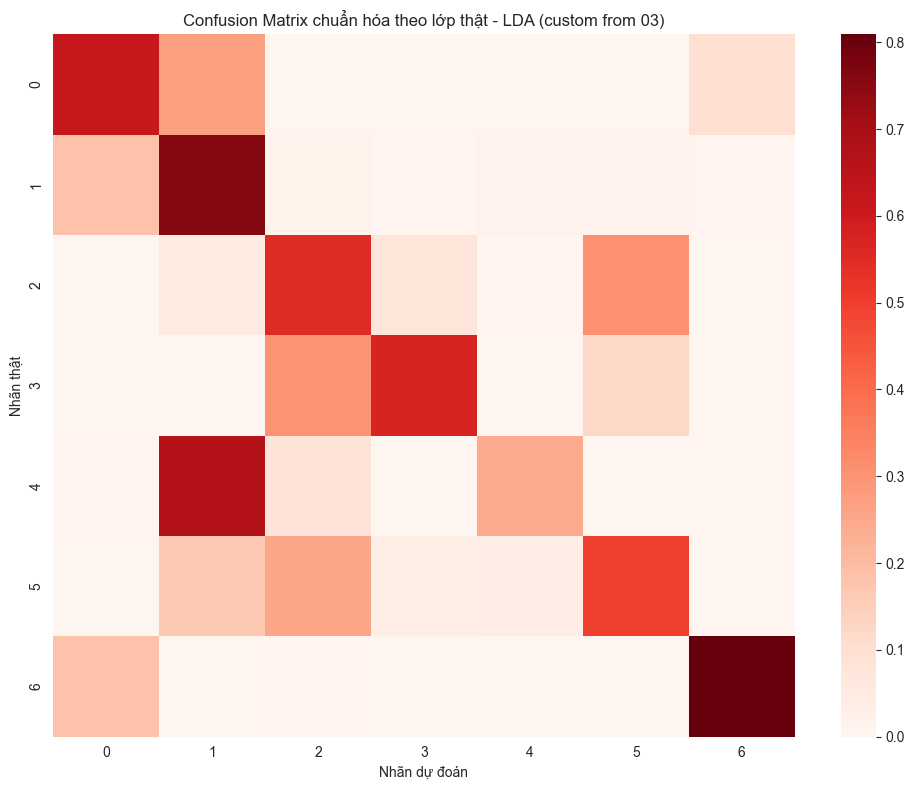

In [14]:
best_model_name = summary_df.iloc[0]['model']
worst_model_name = summary_df.iloc[-1]['model']

print(f'Mô hình tốt nhất: {best_model_name}')
print(f'Mô hình kém nhất: {worst_model_name}')

best_pred = predictions[best_model_name]
worst_pred = predictions[worst_model_name]

# 1) Tỷ lệ lỗi theo lớp của mô hình tốt nhất
per_class_error = []
for c in class_labels:
    mask = (y_test == c)
    err = np.mean(best_pred[mask] != y_test[mask])
    per_class_error.append({'class': int(c), 'error_rate': float(err), 'support': int(mask.sum())})

per_class_error_df = pd.DataFrame(per_class_error).sort_values(by='error_rate', ascending=False)
print('\n=== Tỷ lệ lỗi theo lớp (mô hình tốt nhất) ===')
print(per_class_error_df.to_string(index=False))

# 2) Top cặp nhầm lẫn lớn nhất (mô hình tốt nhất)
cm_best = confusion_matrix(y_test, best_pred, labels=class_labels)
cm_offdiag = cm_best.copy()
np.fill_diagonal(cm_offdiag, 0)

pairs = []
for i, true_c in enumerate(class_labels):
    for j, pred_c in enumerate(class_labels):
        if i != j and cm_offdiag[i, j] > 0:
            pairs.append({'true_class': int(true_c), 'pred_class': int(pred_c), 'count': int(cm_offdiag[i, j])})

top_confusions_df = pd.DataFrame(pairs).sort_values(by='count', ascending=False).head(10)
print('\n=== Top 10 cặp nhầm lẫn (mô hình tốt nhất) ===')
print(top_confusions_df.to_string(index=False))

# 3) Hard cases: mẫu mà cả mô hình tốt nhất và kém nhất đều sai
hard_mask = (best_pred != y_test) & (worst_pred != y_test)
hard_indices = np.where(hard_mask)[0]
print(f'\nSố hard cases (cả 2 mô hình cùng sai): {len(hard_indices)}')

if len(hard_indices) > 0:
    sample_hard = hard_indices[:10]
    hard_df = pd.DataFrame({
        'idx': sample_hard,
        'y_true': y_test[sample_hard],
        'best_pred': best_pred[sample_hard],
        'worst_pred': worst_pred[sample_hard],
    })
    print('\n=== Ví dụ hard cases (10 mẫu đầu) ===')
    print(hard_df.to_string(index=False))

plt.figure(figsize=(10, 8))
cm_norm = cm_best / np.maximum(cm_best.sum(axis=1, keepdims=True), 1)
sns.heatmap(cm_norm, cmap='Reds', cbar=True)
plt.title(f'Confusion Matrix chuẩn hóa theo lớp thật - {best_model_name}')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thật')
plt.tight_layout()
plt.show()

### Phân tích kết quả
- Error analysis xác nhận **LDA** là mô hình tốt nhất hiện tại, còn **QDA** là thấp nhất theo `summary_df`.
- Với LDA, lớp lỗi cao nhất là lớp `5` (`error_rate = 0.7588`), tiếp theo là lớp `6` (`0.5007`) và lớp `3` (`0.4472`).
- Cặp nhầm lẫn lớn nhất là `1 -> 2` (11566) và `2 -> 1` (10443), cho thấy hai lớp này cần ưu tiên cải thiện đặc trưng/phân tách.
- Số hard cases (cả best và worst cùng sai) là `32158`, gợi ý có một nhóm mẫu khó cố hữu của dữ liệu.

## 12) Tổng kết và đề xuất
### Tổng kết kết quả
- Notebook 04 hiện đánh giá trực tiếp các mô hình custom export từ notebook 03 theo schema mới, không fit lại mô hình thư viện trong luồng chính.
- Trong lần chạy này, **LDA (custom from 03)** là mô hình đa lớp tốt nhất theo macro-F1 (`0.5123`), trong khi **Newton-IRLS** tốt nhất ở nhánh binary OVR (`AUC = 0.8426`, `Brier = 0.1552`).
- Bộ đánh giá đã bao phủ đầy đủ: Accuracy, Precision/Recall/F1 theo lớp, confusion matrix, ROC/AUC nhị phân, loss theo iterations/time, decision boundary 2D, bảng so sánh hợp nhất, CV, PR/AP, McNemar, calibration và error analysis.

### Đề xuất điều chỉnh tiếp theo
1. Nếu mục tiêu chính là cân bằng theo lớp, chọn LDA làm baseline triển khai và tập trung giảm nhầm lẫn cặp lớp 1-2.
2. Nếu cần cải thiện chất lượng xác suất nhị phân OVR, ưu tiên Newton-IRLS cho nhánh logistic binary.
3. Mở rộng `custom_cv_summary` trong notebook 03 cho toàn bộ mô hình custom để notebook 04 có thể báo cáo CV đồng nhất hơn (không chỉ L1/L2).